In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 0. Завантажуємо дані (щоб змінна df точно існувала)
!wget -q https://archive.ics.uci.edu/ml/machine-learning-databases/00602/DryBeanDataset.zip
!unzip -q -o DryBeanDataset.zip
df = pd.read_excel('DryBeanDataset/Dry_Bean_Dataset.xlsx')

# 1. Відбір ознак (видалили корельовані ознаки, залишили Area)
features_to_drop = ['Perimeter', 'ConvexArea', 'EquivDiameter', 'MajorAxisLength']
df_reduced = df.drop(columns=features_to_drop)
print(f"Кількість ознак після видалення сильно корельованих: {df_reduced.shape[1] - 1}")

# 2. Кодування цільової змінної (One-Hot Encoding тексту в 0 та 1)
X = df_reduced.drop('Class', axis=1).values
Y_labels = df_reduced['Class'].values
Y_onehot = pd.get_dummies(df_reduced['Class']).astype(int).values

# 3. Розбиття вибірки на 3 частини: Global Test, Global Validation, FL Train Pool
X_temp, X_global_test, Y_temp, Y_global_test = train_test_split(
    X, Y_onehot, test_size=0.15, random_state=42, stratify=Y_onehot
)

X_fl_train, X_global_val, Y_fl_train, Y_global_val = train_test_split(
    X_temp, Y_temp, test_size=0.1765, random_state=42, stratify=Y_temp
)

print(f"\nРозміри вибірок:")
print(f"FL Train Pool: X={X_fl_train.shape}, Y={Y_fl_train.shape}")
print(f"Global Validation: X={X_global_val.shape}, Y={Y_global_val.shape}")
print(f"Global Test: X={X_global_test.shape}, Y={Y_global_test.shape}")

# 4. Масштабування (StandardScaler)
scaler = StandardScaler()
X_fl_train_scaled = scaler.fit_transform(X_fl_train) # Навчаємо тільки на тренувальній!
X_global_val_scaled = scaler.transform(X_global_val)
X_global_test_scaled = scaler.transform(X_global_test)

print("\nДані успішно завантажено та масштабовано без витоку (Data Leakage)!")

Кількість ознак після видалення сильно корельованих: 12

Розміри вибірок:
FL Train Pool: X=(9527, 12), Y=(9527, 7)
Global Validation: X=(2042, 12), Y=(2042, 7)
Global Test: X=(2042, 12), Y=(2042, 7)

Дані успішно завантажено та масштабовано без витоку (Data Leakage)!


#У датасеті відсутні пропущені значення. Цільова змінна має 7 класів із невеликим дисбалансом (найбільший клас - DERMASON, найменший - BOMBAY). Аналіз матриці кореляцій виявив сильну мультиколінеарність між ознаками Area, Perimeter,MajorAxisLength, ConvexArea та EquivDiameter (коефіцієнти кореляції близькі до 1)

# Щоб уникнути надмірної складності моделі та проблеми мультиколінеарності, залишено лише базову ознаку Area. Розбиття на вибірки та масштабування проведено коректно, без витоку даних (Data Leakage) - метод fit для масштабування застосовано виключно до тренувальної вибірки.

Інформація про датасет
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  ob

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


/tmp/ipykernel_2018/1068510070.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Class', palette='viridis')


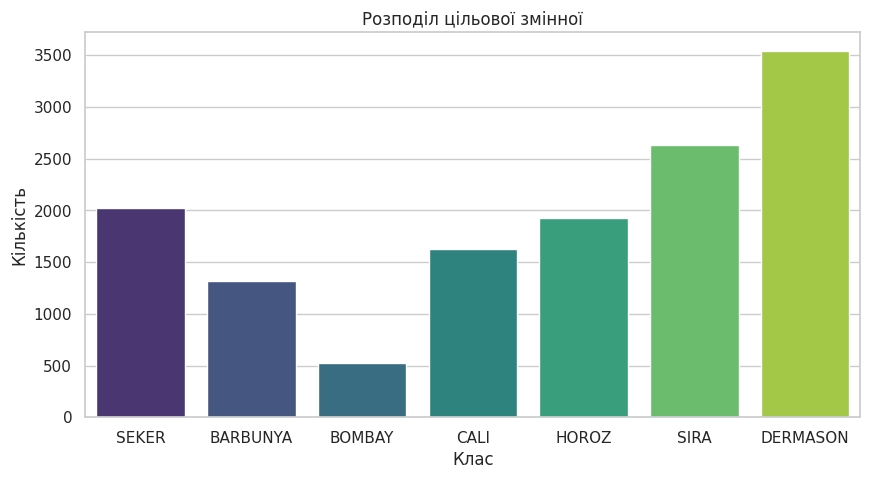

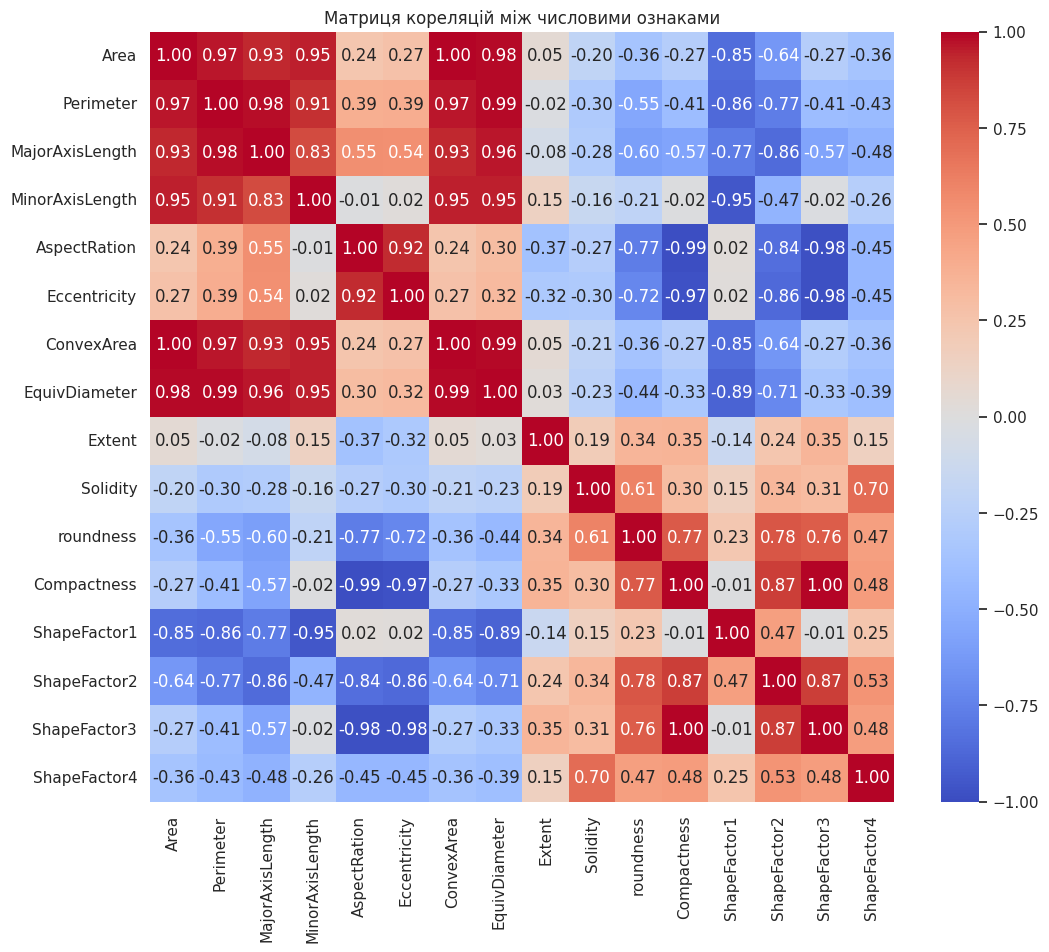

In [3]:
#1 Структура датасету та ознаки
print("Інформація про датасет")
df.info()

#2 пропушені значення
print("\n Кількість пропущених значень у кожній колонці")
print(df.isnull().sum())

#3 основні статистики числових ознак
print("\n Основні статистики")
display(df.describe())

#4 розподіл цільової змінної
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Class', palette='viridis')
plt.title('Розподіл цільової змінної')
plt.ylabel('Кількість')
plt.xlabel('Клас')
plt.show()

#5 кореляції між ознаками
plt.figure(figsize=(12, 10))
#відкнув цільову змінну, оскільки вона категорія
numeric_df = df.drop('Class', axis=1)
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Матриця кореляцій між числовими ознаками')
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

#1 Відбір ознак (видалив корельовані ознаки, залишив Area)
features_to_drop = ['Perimeter', 'ConvexArea', 'EquivDiameter', 'MajorAxisLength']
df_reduced = df.drop(columns=features_to_drop)

print(f"Кількість ознак після видалення сильно корельованих: {df_reduced.shape[1] - 1}")

#2 Кодування цільової змінно
#pandas.get_dummies робить One-Hot Encoding тексту в 0 та 1
X = df_reduced.drop('Class', axis=1).values
Y_labels = df_reduced['Class'].values
Y_onehot = pd.get_dummies(df_reduced['Class']).astype(int).values

#3 Розбиття вибірки на 3 частини: Global Test (15%), Global Validation (15%), FL Train Pool (70%)
#стратифікація (stratify) зберігає пропорції класів у всіх вибірках
X_temp, X_global_test, Y_temp, Y_global_test = train_test_split(
    X, Y_onehot, test_size=0.15, random_state=42, stratify=Y_onehot
)

X_fl_train, X_global_val, Y_fl_train, Y_global_val = train_test_split(
    X_temp, Y_temp, test_size=0.1765, random_state=42, stratify=Y_temp
    #0.1765 від 85% це приблизно 15% від початкового датасету
)

print(f"\nРозміри вибірок:")
print(f"FL Train Pool: X={X_fl_train.shape}, Y={Y_fl_train.shape}")
print(f"Global Validation: X={X_global_val.shape}, Y={Y_global_val.shape}")
print(f"Global Test: X={X_global_test.shape}, Y={Y_global_test.shape}")

#4 Масштабування (StandardScaler)
#!!!!Навчаємо скалер (fit) ТІЛЬКИ на тренувальних даних (FL Train Pool),
#щоб уникнути Data Leakage (витоку даних з тесту)
scaler = StandardScaler()
X_fl_train_scaled = scaler.fit_transform(X_fl_train)

#Застосовую вже навчений скалер (transform) до валідації та тесту
X_global_val_scaled = scaler.transform(X_global_val)
X_global_test_scaled = scaler.transform(X_global_test)

print("\nДані успішно масштабовано без витоку (Data Leakage)")

Кількість ознак після видалення сильно корельованих: 12

Розміри вибірок:
FL Train Pool: X=(9527, 12), Y=(9527, 7)
Global Validation: X=(2042, 12), Y=(2042, 7)
Global Test: X=(2042, 12), Y=(2042, 7)

Дані успішно масштабовано без витоку (Data Leakage)


In [5]:
class MultinomialLogisticRegression:
    def __init__(self, learning_rate=0.01, epochs=100, batch_size=32, lambda_reg=0.1):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.lambda_reg = lambda_reg #Параметр Ridge-регуляризації
        self.W = None #Матриця ваг
        self.b = None #Вектор зміщення

    def softmax(self, Z):
        #Віднімання максимуму рядка для числової стабільності
        Z_shifted = Z - np.max(Z, axis=1, keepdims=True)
        exp_Z = np.exp(Z_shifted)
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

    def predict_proba(self, X):
        Z = np.dot(X, self.W) + self.b
        return self.softmax(Z)

    def predict(self, X):
        P = self.predict_proba(X)
        return np.argmax(P, axis=1)

    def loss(self, X, Y):
        m = X.shape[0]
        P = self.predict_proba(X)
        #Додаємо epsilon (1e-15), щоб уникнути log(0)
        cross_entropy = - (1/m) * np.sum(Y * np.log(P + 1e-15))
        #Додаємо Ridge (L2) регуляризацію (штраф тільки для матриці W)
        ridge_penalty = (self.lambda_reg / 2) * np.sum(np.square(self.W))
        return cross_entropy + ridge_penalty

    def compute_gradients(self, X, Y, P):
        m = X.shape[0]
        #Градієнт по вагах W: (X^T * (P - Y)) / m + lambda * W
        dW = (1/m) * np.dot(X.T, (P - Y)) + self.lambda_reg * self.W
        #Градієнт по зсуву b: сума по стовпцях (P - Y) / m
        db = (1/m) * np.sum(P - Y, axis=0, keepdims=True)
        return dW, db

    def fit(self, X, Y, X_val=None, Y_val=None, print_every=10):
        m, d = X.shape
        _, C = Y.shape #C - кількість класів

        #Ініціалізація ваг та зміщень нулями
        if self.W is None:
            self.W = np.zeros((d, C))
            self.b = np.zeros((1, C))

        history = {'loss': [], 'val_accuracy': []}

        for epoch in range(self.epochs):
            #Перемішування даних для міні-батчів
            indices = np.random.permutation(m)
            X_shuffled = X[indices]
            Y_shuffled = Y[indices]

            #Навчання по міні-батчах
            for i in range(0, m, self.batch_size):
                X_batch = X_shuffled[i:i+self.batch_size]
                Y_batch = Y_shuffled[i:i+self.batch_size]

                #Прямий прохід
                P_batch = self.predict_proba(X_batch)

                #Обчислення градієнтів
                dW, db = self.compute_gradients(X_batch, Y_batch, P_batch)

                #Оновлення параметрів
                self.W -= self.learning_rate * dW
                self.b -= self.learning_rate * db

            #Запис метрик після кожної епохи
            current_loss = self.loss(X, Y)
            history['loss'].append(current_loss)

            if X_val is not None and Y_val is not None:
                val_preds = self.predict(X_val)
                val_true = np.argmax(Y_val, axis=1)
                val_acc = np.mean(val_preds == val_true)
                history['val_accuracy'].append(val_acc)

                if (epoch + 1) % print_every == 0:
                    print(f"Epoch {epoch+1}/{self.epochs} - Loss: {current_loss:.4f} - Val Acc: {val_acc:.4f}")

        return history

print("Logistic regression class completed")

Logistic regression class completed


Починаємо навчання централізованої моделі...
Epoch 25/150 - Loss: 0.4820 - Val Acc: 0.9216
Epoch 50/150 - Loss: 0.4812 - Val Acc: 0.9207
Epoch 75/150 - Loss: 0.4813 - Val Acc: 0.9197
Epoch 100/150 - Loss: 0.4811 - Val Acc: 0.9212
Epoch 125/150 - Loss: 0.4814 - Val Acc: 0.9212
Epoch 150/150 - Loss: 0.4812 - Val Acc: 0.9212


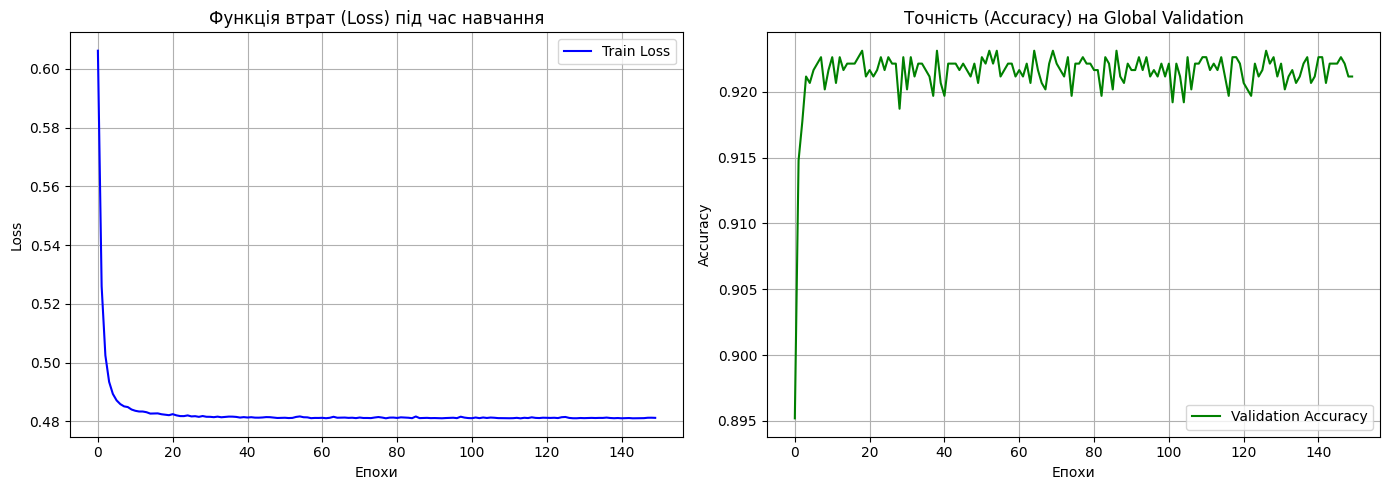


--- Оцінка централізованої моделі на Global Test ---
Accuracy:          0.9163
Macro-F1:          0.9262
Balanced Accuracy: 0.9249
Log-Loss:          0.3488


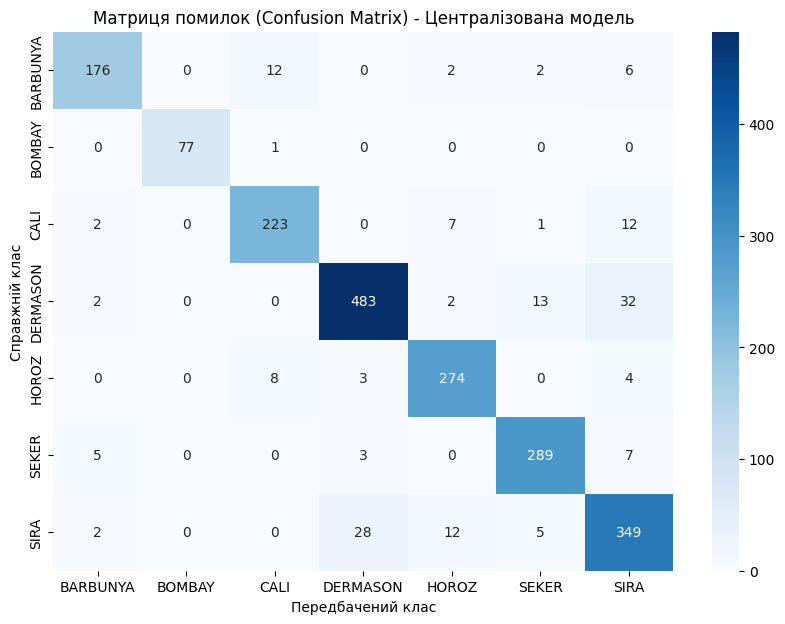

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, log_loss, confusion_matrix

#1 Ініціалізація моделі з гіперпараметрами
#learning_rate=0.1 та epochs=150 зазвичай добре працюють для масштабованих даних
model_centralized = MultinomialLogisticRegression(
    learning_rate=0.1,
    epochs=150,
    batch_size=64,
    lambda_reg=0.01
)

#2 Навчання моделі на FL Train Pool
print("Починаємо навчання централізованої моделі...")
history = model_centralized.fit(
    X_fl_train_scaled, Y_fl_train,
    X_val=X_global_val_scaled, Y_val=Y_global_val,
    print_every=25
)

#3 Побудова графіків навчання (Loss та Accuracy)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(history['loss'], label='Train Loss', color='blue')
ax[0].set_title('Функція втрат (Loss) під час навчання')
ax[0].set_xlabel('Епохи')
ax[0].set_ylabel('Loss')
ax[0].grid(True)
ax[0].legend()

ax[1].plot(history['val_accuracy'], label='Validation Accuracy', color='green')
ax[1].set_title('Точність (Accuracy) на Global Validation')
ax[1].set_xlabel('Епохи')
ax[1].set_ylabel('Accuracy')
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()

#4 Фінальна оцінка на Global Test
print("\n--- Оцінка централізованої моделі на Global Test ---")
P_test = model_centralized.predict_proba(X_global_test_scaled)
preds_test = model_centralized.predict(X_global_test_scaled)
true_test = np.argmax(Y_global_test, axis=1)

#Обчислення метрик згідно з вимогами
acc = accuracy_score(true_test, preds_test)
macro_f1 = f1_score(true_test, preds_test, average='macro')
bal_acc = balanced_accuracy_score(true_test, preds_test)
test_log_loss = log_loss(Y_global_test, P_test)

print(f"Accuracy:          {acc:.4f}")
print(f"Macro-F1:          {macro_f1:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")
print(f"Log-Loss:          {test_log_loss:.4f}")

#5 Побудова Confusion Matrix
cm = confusion_matrix(true_test, preds_test)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(Y_labels),
            yticklabels=np.unique(Y_labels))
plt.title('Матриця помилок (Confusion Matrix) - Централізована модель')
plt.xlabel('Передбачений клас')
plt.ylabel('Справжній клас')
plt.show()

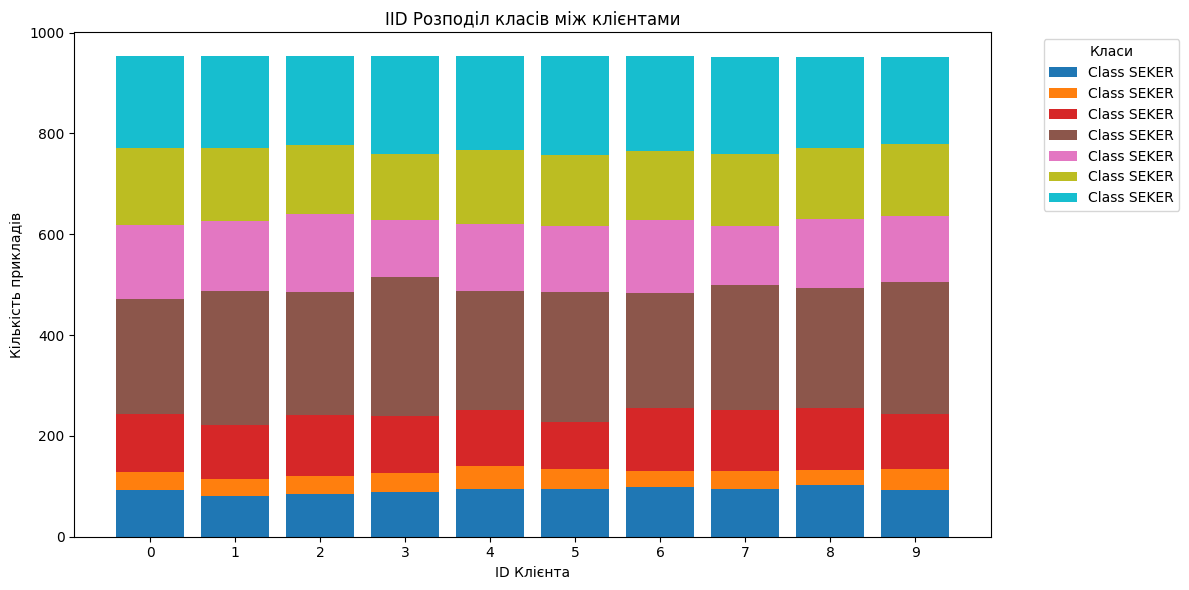

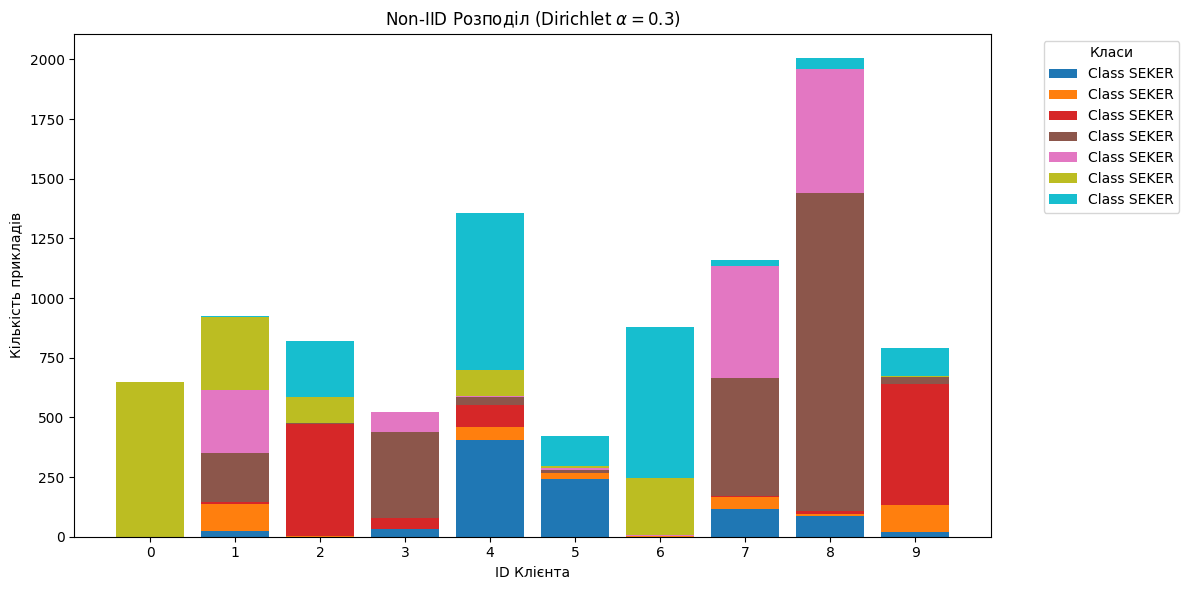

In [9]:
def distribute_data_iid(X, Y, num_clients):
    """
    Рівномірний (IID) розподіл даних між клієнтами.
    """
    m = X.shape[0]
    indices = np.random.permutation(m)
    X_shuffled, Y_shuffled = X[indices], Y[indices]

    # Розбиваємо масиви на num_clients приблизно рівних частин
    X_clients = np.array_split(X_shuffled, num_clients)
    Y_clients = np.array_split(Y_shuffled, num_clients)

    return X_clients, Y_clients

def distribute_data_dirichlet(X, Y, num_clients, alpha):
    """
    Неоднорідний (Non-IID) розподіл за допомогою розподілу Діріхле.
    """
    num_classes = Y.shape[1]
    X_clients = [[] for _ in range(num_clients)]
    Y_clients = [[] for _ in range(num_clients)]

    # Знаходимо індекси прикладів для кожного класу
    class_indices = [np.where(np.argmax(Y, axis=1) == c)[0] for c in range(num_classes)]

    for c in range(num_classes):
        idx = class_indices[c]
        np.random.shuffle(idx)

        #Пропорції з розподілу Діріхле для поточного класу
        proportions = np.random.dirichlet(np.repeat(alpha, num_clients))

        # Масштабував пропорції до кількості прикладів цього класу
        splits = np.round(proportions * len(idx)).astype(int)

        #Коригував можливі помилки округлення, щоб сума збігалася з кількістю елементів
        splits[-1] = len(idx) - np.sum(splits[:-1])

        #Розподілив індекси класу c між клієнтами
        current_idx = 0
        for k in range(num_clients):
            k_indices = idx[current_idx:current_idx + splits[k]]
            X_clients[k].extend(X[k_indices])
            Y_clients[k].extend(Y[k_indices])
            current_idx += splits[k]

    #Перетворив списки назад у масиви numpy та перемішуємо локальні дані клієнтів
    for k in range(num_clients):
        X_clients[k] = np.array(X_clients[k])
        Y_clients[k] = np.array(Y_clients[k])

        local_indices = np.random.permutation(len(X_clients[k]))
        X_clients[k] = X_clients[k][local_indices]
        Y_clients[k] = Y_clients[k][local_indices]

    return X_clients, Y_clients

def plot_client_distribution(Y_clients, title):
    """
    Візуалізація розподілу класів між клієнтами (стовпчикова діаграма).
    """
    num_clients = len(Y_clients)
    num_classes = Y_clients[0].shape[1]

    #Розрахував кількість прикладів кожного класу для кожного клієнта
    class_counts = np.zeros((num_clients, num_classes))
    for k in range(num_clients):
        if len(Y_clients[k]) > 0:
            class_counts[k] = np.sum(Y_clients[k], axis=0)

    #Побудова графіка
    fig, ax = plt.subplots(figsize=(12, 6))
    bottom = np.zeros(num_clients)

    colors = plt.cm.tab10(np.linspace(0, 1, num_classes))

    for c in range(num_classes):
        ax.bar(range(num_clients), class_counts[:, c], bottom=bottom, label=f'Class {Y_labels[c]}', color=colors[c])
        bottom += class_counts[:, c]

    ax.set_title(title)
    ax.set_xlabel('ID Клієнта')
    ax.set_ylabel('Кількість прикладів')
    ax.set_xticks(range(num_clients))
    ax.legend(title='Класи', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

#Розподіл
NUM_CLIENTS = 10

#1 IID розподіл
X_clients_iid, Y_clients_iid = distribute_data_iid(X_fl_train_scaled, Y_fl_train, NUM_CLIENTS)
plot_client_distribution(Y_clients_iid, "IID Розподіл класів між клієнтами")

#2 Non-IID розподіл (сильна неоднорідність, alpha=0.3 згідно з методичкою)
ALPHA = 0.3
X_clients_non_iid, Y_clients_non_iid = distribute_data_dirichlet(X_fl_train_scaled, Y_fl_train, NUM_CLIENTS, ALPHA)
plot_client_distribution(Y_clients_non_iid, f"Non-IID Розподіл (Dirichlet $\\alpha={ALPHA}$)")


# Графіки демонструють стабільне навчання централізованої (базової) моделі: функція втрат (Loss) стрімко спадає та виходить на плато, а точність (Accuracy) на валідаційній вибірці стабілізується на рівні понад 91%

# Матриця помилок підтверджує, що модель впевнено розпізнає більшість класів квасолі (найбільші значення зосереджені на головній діагоналі)

# Ця модель слугуватиме еталоном (baseline) для оцінки ефективності федеративного підходу


Початок: FL на IID даних 
Раунд 1/30 | Global Val Acc: 0.6841 | Loss: 1.1854
Раунд 5/30 | Global Val Acc: 0.8320 | Loss: 0.7336
Раунд 10/30 | Global Val Acc: 0.8972 | Loss: 0.5989
Раунд 15/30 | Global Val Acc: 0.9089 | Loss: 0.5445
Раунд 20/30 | Global Val Acc: 0.9114 | Loss: 0.5173
Раунд 25/30 | Global Val Acc: 0.9172 | Loss: 0.5022
Раунд 30/30 | Global Val Acc: 0.9187 | Loss: 0.4930

Початок: FL на Non-IID даних (Dirichlet 0.3) 
Раунд 1/30 | Global Val Acc: 0.6136 | Loss: 1.2696
Раунд 5/30 | Global Val Acc: 0.8105 | Loss: 0.7820
Раунд 10/30 | Global Val Acc: 0.8815 | Loss: 0.6359
Раунд 15/30 | Global Val Acc: 0.9025 | Loss: 0.5772
Раунд 20/30 | Global Val Acc: 0.9045 | Loss: 0.5463
Раунд 25/30 | Global Val Acc: 0.9089 | Loss: 0.5280
Раунд 30/30 | Global Val Acc: 0.9114 | Loss: 0.5175


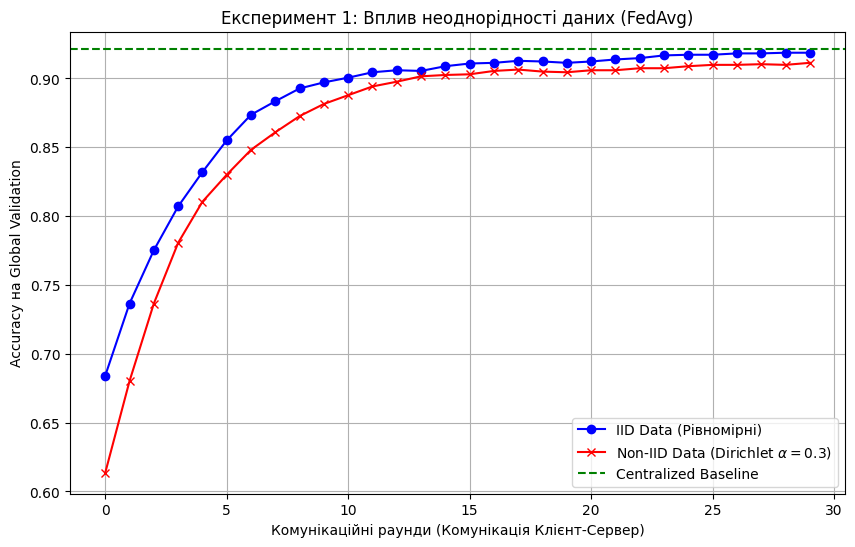

In [10]:
import copy

def federated_learning_simulation(X_clients, Y_clients, X_val, Y_val,
                                  num_rounds=20, local_epochs=1, lr=0.1,
                                  lambda_reg=0.01, title="FL Simulation"):
    num_clients = len(X_clients)
    _, d = X_clients[0].shape
    _, C = Y_clients[0].shape

    #Ініціалізація глобальної моделі сервером
    global_model = MultinomialLogisticRegression(learning_rate=lr, epochs=local_epochs, lambda_reg=lambda_reg)
    global_model.W = np.zeros((d, C))
    global_model.b = np.zeros((1, C))

    #Розрахував кількість прикладів для зважування (n_k / N)
    total_samples = sum([len(X) for X in X_clients])

    history = {'val_accuracy': [], 'val_loss': []}
    print(f"\nПочаток: {title} ")

    for round_num in range(num_rounds):
        #Масиви для накопичення оновлень від клієнтів
        global_W_new = np.zeros_like(global_model.W)
        global_b_new = np.zeros_like(global_model.b)

        #Локальне навчання на клієнтах
        for k in range(num_clients):
            if len(X_clients[k]) == 0:
                continue #Пропускаємо клієнта, якщо у нього зовсім немає даних

            #Клієнт завантажує актуальну глобальну модель
            local_model = MultinomialLogisticRegression(learning_rate=lr, epochs=local_epochs, batch_size=64, lambda_reg=lambda_reg)
            local_model.W = np.copy(global_model.W)
            local_model.b = np.copy(global_model.b)

            #Тренування локальної моделі (print_every=1000 щоб не виводити логів клієнтів)
            local_model.fit(X_clients[k], Y_clients[k], print_every=1000)

            #Агрегація FedAvg: зважування ваг за кількістю прикладів клієнта
            weight = len(X_clients[k]) / total_samples
            global_W_new += local_model.W * weight
            global_b_new += local_model.b * weight

        #Оновлення глобальної моделі на сервері
        global_model.W = global_W_new
        global_model.b = global_b_new

        #Оцінка глобальної моделі на Global Validation після раунду
        val_preds = global_model.predict(X_val)
        val_true = np.argmax(Y_val, axis=1)
        val_acc = np.mean(val_preds == val_true)
        val_loss = global_model.loss(X_val, Y_val)

        history['val_accuracy'].append(val_acc)
        history['val_loss'].append(val_loss)

        if (round_num + 1) % 5 == 0 or round_num == 0:
            print(f"Раунд {round_num+1}/{num_rounds} | Global Val Acc: {val_acc:.4f} | Loss: {val_loss:.4f}")

    return global_model, history

#Виконав Експеримент 1: Вплив неоднорідності
ROUNDS = 30
LOCAL_EPOCHS = 1 # E=1

#1 Запуск FL на рівномірних (IID) даних
global_model_iid, history_iid = federated_learning_simulation(
    X_clients_iid, Y_clients_iid, X_global_val_scaled, Y_global_val,
    num_rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, title="FL на IID даних"
)

#2 Запуск FL на неоднорідних (Non-IID) даних (Dirichlet alpha=0.3)
global_model_non_iid, history_non_iid = federated_learning_simulation(
    X_clients_non_iid, Y_clients_non_iid, X_global_val_scaled, Y_global_val,
    num_rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, title="FL на Non-IID даних (Dirichlet 0.3)"
)

#Експеримент 1
plt.figure(figsize=(10, 6))
plt.plot(history_iid['val_accuracy'], label='IID Data (Рівномірні)', color='blue', marker='o')
plt.plot(history_non_iid['val_accuracy'], label='Non-IID Data (Dirichlet $\\alpha=0.3$)', color='red', marker='x')

#Додав лінію точності централізованої моделі для порівняння (яку ми отримали на Етапі 3)
centralized_acc = np.mean(model_centralized.predict(X_global_val_scaled) == np.argmax(Y_global_val, axis=1))
plt.axhline(y=centralized_acc, color='green', linestyle='--', label='Centralized Baseline')

plt.title('Експеримент 1: Вплив неоднорідності даних (FedAvg)')
plt.xlabel('Комунікаційні раунди (Комунікація Клієнт-Сервер)')
plt.ylabel('Accuracy на Global Validation')
plt.grid(True)
plt.legend()
plt.show()

# На графіках візуалізовано два підходи до розподілу тренувального пулу даних. У випадку IID-розподілу кожен клієнт отримав однакову кількість прикладів із повним збереженням глобальних пропорцій класів

# У випадку Non-IID розподілу (за допомогою розподілу Діріхле з alpha=0.3) спостерігається яскраво виражена неоднорідність: обсяг даних у клієнтів суттєво відрізняється, а в окремих локальних вибірках домінують лише 1-2 класи, тоді як інші відсутні

Експеримент 2: Запуск FL з різною кількістю локальних епох (E) на Non-IID даних 

Початок: FL (Non-IID, E=1) 
Раунд 1/20 | Global Val Acc: 0.6268 | Loss: 1.2673
Раунд 5/20 | Global Val Acc: 0.8105 | Loss: 0.7824
Раунд 10/20 | Global Val Acc: 0.8795 | Loss: 0.6370
Раунд 15/20 | Global Val Acc: 0.9025 | Loss: 0.5771
Раунд 20/20 | Global Val Acc: 0.9045 | Loss: 0.5467

Початок: FL (Non-IID, E=5) 
Раунд 1/20 | Global Val Acc: 0.8178 | Loss: 0.9395
Раунд 5/20 | Global Val Acc: 0.8991 | Loss: 0.5913
Раунд 10/20 | Global Val Acc: 0.9016 | Loss: 0.5388
Раунд 15/20 | Global Val Acc: 0.9060 | Loss: 0.5259
Раунд 20/20 | Global Val Acc: 0.9065 | Loss: 0.5205

Початок: FL (Non-IID, E=10) 
Раунд 1/20 | Global Val Acc: 0.8624 | Loss: 0.8302
Раунд 5/20 | Global Val Acc: 0.8942 | Loss: 0.5725
Раунд 10/20 | Global Val Acc: 0.8957 | Loss: 0.5475
Раунд 15/20 | Global Val Acc: 0.8967 | Loss: 0.5441
Раунд 20/20 | Global Val Acc: 0.8972 | Loss: 0.5422


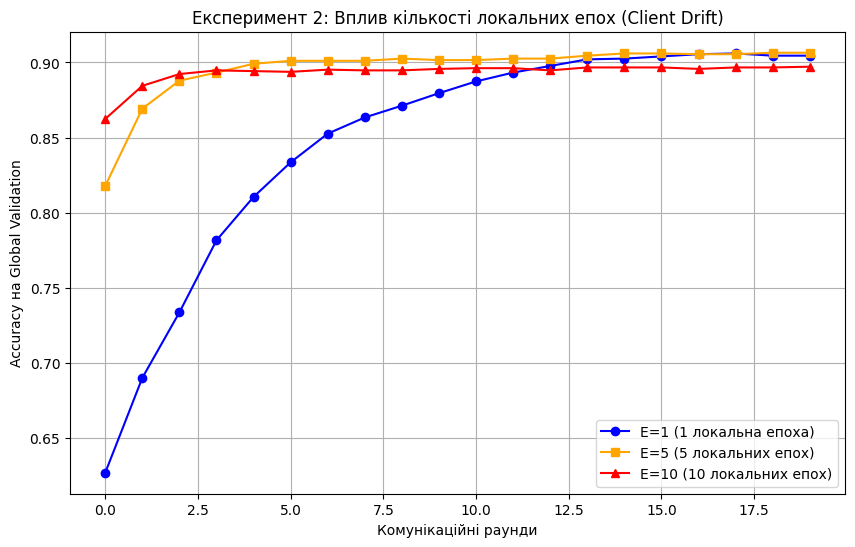


 Фінальне порівняння моделей на Global Test 


,Тип моделі,Accuracy,Macro-F1,Balanced Accuracy,Log-Loss
0,Локальна (Тільки дані Клієнта 0),0.1606,0.0565,0.1602,2.6915
1,Глобальна (Федеративна IID),0.9143,0.9250,0.9247,0.4070
2,Централізована (Всі дані),0.9163,0.9262,0.9249,0.3488


In [11]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, log_loss

#Експеримент 2 : Вплив кількості локальних епох (Client Drift)
print("Експеримент 2: Запуск FL з різною кількістю локальних епох (E) на Non-IID даних ")
ROUNDS = 20 #Встановив 20 раундів для швидкості експерименту

#Запустив для E=1
_, hist_E1 = federated_learning_simulation(
    X_clients_non_iid, Y_clients_non_iid, X_global_val_scaled, Y_global_val,
    num_rounds=ROUNDS, local_epochs=1, title="FL (Non-IID, E=1)"
)

#Запустив для E=5
_, hist_E5 = federated_learning_simulation(
    X_clients_non_iid, Y_clients_non_iid, X_global_val_scaled, Y_global_val,
    num_rounds=ROUNDS, local_epochs=5, title="FL (Non-IID, E=5)"
)

#Запустив для E=10
_, hist_E10 = federated_learning_simulation(
    X_clients_non_iid, Y_clients_non_iid, X_global_val_scaled, Y_global_val,
    num_rounds=ROUNDS, local_epochs=10, title="FL (Non-IID, E=10)"
)

#Побудова графіка для Експерименту 2
plt.figure(figsize=(10, 6))
plt.plot(hist_E1['val_accuracy'], label='E=1 (1 локальна епоха)', marker='o', color='blue')
plt.plot(hist_E5['val_accuracy'], label='E=5 (5 локальних епох)', marker='s', color='orange')
plt.plot(hist_E10['val_accuracy'], label='E=10 (10 локальних епох)', marker='^', color='red')
plt.title('Експеримент 2: Вплив кількості локальних епох (Client Drift)')
plt.xlabel('Комунікаційні раунди')
plt.ylabel('Accuracy на Global Validation')
plt.grid(True)
plt.legend()
plt.show()

#Порівняння трьох типів моделей на Global Test
print("\n Фінальне порівняння моделей на Global Test ")

def evaluate_on_test(model, name):
    P = model.predict_proba(X_global_test_scaled)
    preds = model.predict(X_global_test_scaled)
    true = np.argmax(Y_global_test, axis=1)

    return {
        'Тип моделі': name,
        'Accuracy': round(accuracy_score(true, preds), 4),
        'Macro-F1': round(f1_score(true, preds, average='macro'), 4),
        'Balanced Accuracy': round(balanced_accuracy_score(true, preds), 4),
        'Log-Loss': round(log_loss(Y_global_test, P), 4)
    }

#1 Оцінка Централізованої моделі (навченої на Етапі 3)
res_central = evaluate_on_test(model_centralized, 'Централізована (Всі дані)')

#2 Оцінка Глобальної моделі (беремо найкращу FL модель з IID даних)
res_global = evaluate_on_test(global_model_iid, 'Глобальна (Федеративна IID)')

#3 Навчання та оцінка Локальної моделі (навчаємо тільки на даних одного клієнта з Non-IID)
local_client_model = MultinomialLogisticRegression(learning_rate=0.1, epochs=100, lambda_reg=0.01)
local_client_model.fit(X_clients_non_iid[0], Y_clients_non_iid[0], print_every=1000) # Навчаємо на даних Клієнта 0
res_local = evaluate_on_test(local_client_model, 'Локальна (Тільки дані Клієнта 0)')

#Створення таблиці
results_df = pd.DataFrame([res_local, res_global, res_central])
display(results_df)


# Висновки до експериментів та фінальної оцінки моделей

* Експеримент 1 (Вплив неоднорідності): Федеративна модель на IID-даних навчається стабільно і за швидкістю збіжності наближається до централізованої базової лінії. Натомість Non-IID дані суттєво уповільнюють збіжність та знижують фінальну точність через перекоси в локальних оптимумах клієнтів

* Експеримент 2 (Client Drift): Збільшення кількості локальних епох (E=10) на неоднорідних (Non-IID) даних призводить до явища "клієнтського дрейфу". Локальні моделі надмірно підлаштовуються під специфічні класи своїх клієнтів і відхиляються від глобального оптимуму, що після агрегації на сервері дає значно гіршу та нестабільнішу глобальну модель порівняно з E=1

# Фінальне порівняння:

Локальна клієнтська модель, навчена виключно на Non-IID даних одного вузла, не здатна до узагальнення (Accuracy ~16%), оскільки навчалася лише на специфічній підмножині класів. Глобальна федеративна модель (IID) показала високу якість (Accuracy ~91.4%), яка майже відповідає ідеальній централізованій моделі (Accuracy ~91.6%), успішно вирішивши задачу класифікації за умови повного збереження конфіденційності локальних даних клієнтів

# Відповіді на теоретичні питання

1. **Чому для багатокласової класифікації використовують softmax?**
   Softmax перетворює сирі лінійні виходи моделі (логіти) у розподіл імовірностей — усі значення стають додатними, а їхня сума для кожного прикладу дорівнює одиниці. Це дозволяє легко визначити найімовірніший клас.

2. **Чому крос-ентропія є природною функцією втрат для логістичної регресії?**
   Крос-ентропія математично походить від принципу максимальної правдоподібності (Maximum Likelihood Estimation). Вона сильно штрафує модель, якщо та впевнено прогнозує неправильний клас.

3. **Чим відрізняється Ridge-регуляризація від Lasso?**
   Ridge (L2) штрафує за суму квадратів ваг, що призводить до їх рівномірного зменшення, уникаючи надмірно великих значень коефіцієнтів. Lasso (L1) штрафує за суму модулів ваг, що може занулювати деякі з них, виконуючи таким чином автоматичний відбір ознак.

4. **Чому параметр зміщення (b) зазвичай не регуляризують?**
   Зсув (bias) не впливає на складність чи "кривизну" розділяючої площини; він лише зсуває її в просторі. Його регуляризація не допомагає зменшити перенавчання (overfitting).

5. **Що таке Data Leakage?**
   Витік даних - це ситуація, коли інформація з тестової або валідаційної вибірки випадково використовується під час навчання (наприклад, масштабування всього датасету до його розбиття на частини). Це дає хибно оптимістичні результати.

6. **Чому тестову вибірку не можна використовувати для підбору гіперпараметрів?**
   Якщо підбирати гіперпараметри, орієнтуючись на тестову вибірку, модель "підлаштується" під неї. Тестова вибірка перестане бути незалежною мірою якості моделі на нових, небачених даних

7. **Чому параметри масштабування потрібно навчати лише на тренувальних даних?**
   Щоб запобігти витоку даних. Середнє значення та дисперсія мають обчислюватися виключно на тренувальній множині і потім застосовуватися до валідаційної та тестової

8. **Що таке федеративне навчання і які його основні переваги?**
   Це метод розподіленого машинного навчання, де модель тренується безпосередньо на пристроях користувачів На центральний сервер відправляються лише оновлені ваги моделі Головні переваги — збереження конфіденційності даних клієнтів та економія мережевого трафіку

9. **Чому сервер не повинен отримувати сирі дані клієнтів?**
   Головна мета федеративного навчання — конфіденційність (privacy) Сервер отримує лише абстрактні ваги, щоб не компрометувати приватну інформацію користувачів

10. **Чому агрегація FedAvg зважує ваги за кількістю прикладів?**
    Клієнти з більшим обсягом даних мають більш репрезентативні вибірки, тому їхні локальні оновлення градієнтів є надійнішими і повинні мати більший вплив на глобальну модель

11. **Що станеться, якщо агрегувати параметри без зважування?**
    Клієнт із 10 прикладами матиме такий самий вплив, як і клієнт із 10 000. Це призведе до того, що глобальна модель зміститься в бік шуму та нерепрезентативних даних маленьких вузлів

12. **Що таке Non-IID дані?**
    Це дані, які не є незалежними та однаково розподіленими (Independent and Identically Distributed). У контексті цієї роботи це означає, що розподіл класів або ознак у кожного клієнта суттєво відрізняється від глобального розподілу

13. **Чому федеративне навчання може погіршуватися на Non-IID даних?**
    Локальні моделі швидко оптимізуються лише під ті класи, які вони бачать, ігноруючи інші. Під час агрегації на сервері ці "вузькоспеціалізовані" моделі погано узагальнюються у єдину точну глобальну модель

14. **Що таке клієнтський дрейф (client drift)?**
    Це явище, коли локальні моделі (особливо на Non-IID даних) під час тривалого локального навчання занадто далеко відхиляються від напрямку оптимізації глобальної моделі

15. **Як кількість локальних епох впливає на глобальну модель?**
    На IID даних збільшення локальних епох може пришвидшити збіжність. Але на Non-IID даних велика кількість локальних епох (наприклад, E=10) сильно посилює клієнтський дрейф, що катастрофічно погіршує загальну якість

16. **Чи може глобальна модель бути гіршою за централізовану модель? Чому?**
    Так. Централізована модель бачить усі дані одночасно і може знайти оптимальний глобальний мінімум. Глобальна модель страждає від втрати інформації при усередненні ваг та від клієнтського дрейфу

17. **Які метрики краще використовувати для багатокласової класифікації з дисбалансом?**
    Звичайна Accuracy є оманливою, оскільки модель може вгадувати лише домінуючий клас. Краще використовувати Balanced Accuracy (усереднена точність по кожному класу незалежно від його розміру) або Macro-F1 (середнє гармонічне між precision та recall для всіх класів)

# Загальний висновок

Метою цієї роботи було дослідження архітектури багатокласової логістичної регресії, її реалізація засобами numpy та симуляція механізмів федеративного навчання. Під час роботи було проведено попередню обробку датасету Dry Bean із дотриманням правил запобігання Data Leakage. Було реалізовано логістичну регресію з використанням функції softmax та крос-ентропії з Ridge-регуляризацією

У ході симуляції федеративного навчання за алгоритмом FedAvg було досліджено два методи розподілу даних між клієнтами: IID та Non-IID (за Діріхле). Проведені експерименти довели вразливість федеративного підходу до неоднорідності даних, а також продемонстрували явище "клієнтського дрейфу" при збільшенні кількості локальних епох. Підсумкове порівняння моделей показало, що глобальна федеративна модель здатна досягати результатів, порівнянних із централізованою базовою лінією, вирішуючи проблему збереження конфіденційності клієнтських даних.